In [2]:
import numpy as np
import matplotlib.pyplot as plt
from turing.kinetics import steady_state
from turing.solver import initial_condition, stable_dt, simulate
from turing.plotting import plot_kymograph, plot_profile

In [3]:
""" 
shape : int for 1D array, tuple for 2D array.
"""
a, b, gamma, shape = 0.1, 0.9, 1000, 200
u0, v0 = initial_condition(shape, a, b)

In [4]:
D, L = 10, 1
dx = L / (shape - 1)
dt = stable_dt(dx, D, 1)
n_steps, save_every = 1e6, 1000

In [5]:
hist_u, hist_v = simulate(u0, v0, a, b, gamma, D, dx, dt, n_steps, save_every)

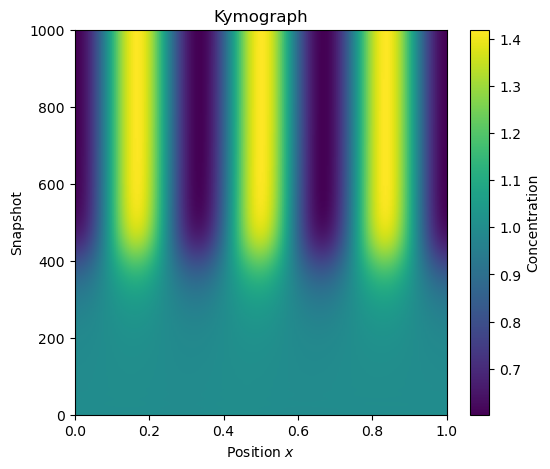

In [6]:
ax = plot_kymograph(history=hist_u, x=np.linspace(0, L, shape))

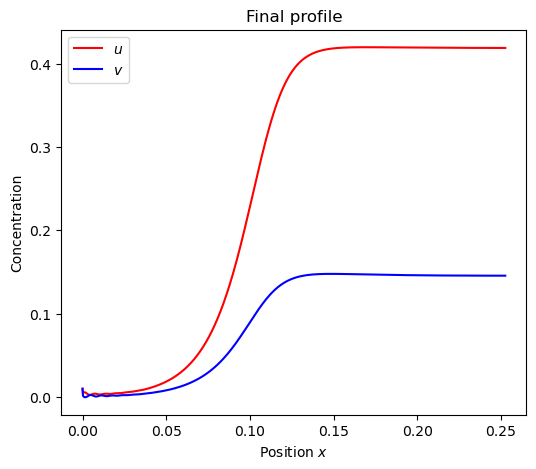

In [7]:
u_star, v_star = steady_state(a, b)
time = np.arange(len(hist_u)) * (dt * save_every)
amplitude_u = hist_u.max(axis=1) - u_star
amplitude_v = hist_v.max(axis=1) - v_star
mask_u = (amplitude_u > 1e-2) & (amplitude_u < 1e-1)

ax2 = plot_profile(u=amplitude_u, v=amplitude_v, x=time)